In [1]:
import os
import base64
import json
import random
from openai import OpenAI
import anthropic
import numpy as np
import re
from tqdm import tqdm
import pandas as pd
import time
import matplotlib.pyplot as plt
from word2number import w2n
from dotenv import load_dotenv
import copy

# Load dataset

In [2]:
# Set base directory using relative path
base_dir = os.path.join(os.getcwd(), "dataset", "simpsons")

# Set paths relative to base_dir
annotation_path = os.path.join(base_dir, "v1_Annotation_Val_simpsons_vqa.json")
question_path = os.path.join(base_dir, "v1_Question_Val_simpsons_vqa.json")
images_dir = os.path.join(base_dir, "val_images")

def load_dataset(annotation_path, question_path):
    try:
        with open(annotation_path, 'r') as f:
            annotations = json.load(f)['annotations']

        with open(question_path, 'r') as f:
            questions = json.load(f)['questions']

        # Select high-quality QA pairs (overall_scores == 1.0)
        filtered_annotations = [
            annotation for annotation in annotations
            if annotation.get('overall_scores', {}).get('question') == 1.0 and
               annotation.get('overall_scores', {}).get('answer') == 1.0
        ]

        # Create a mapping from question ID to answer
        question_id_to_answer = {
            annotation['id']: annotation['answer']
            for annotation in filtered_annotations
        }

        # Create a mapping from question ID to answer type
        question_id_to_answer_type = {
            annotation['id']: {
                'answer': annotation['answer'],
                'answer_type': annotation.get('answer_type', 'other')
            }
            for annotation in filtered_annotations
        }

        filtered_questions = [question for question in questions if question['id'] in question_id_to_answer]

        return filtered_questions, filtered_annotations, question_id_to_answer, question_id_to_answer_type

    except Exception as e:
        print(f"Error loading dataset: {e}")
        return [], [], {}, {}

def get_dataset(questions, question_id_to_answer, fraction=0.005, seed=42):
    # TODO: Increase quantity
# def get_dataset(questions, question_id_to_answer, fraction=0.05, seed=42):
    try:
        random.seed(seed)
        sample_size = max(1, int(len(questions) * fraction))
        sampled_question_items = random.sample(questions, sample_size)
        sampled_correct_answers = [
            question_id_to_answer[q['id']]
            for q in sampled_question_items
        ]
        # Add image_base64 to each sampled question
        for q in sampled_question_items:
            image_relative_path = q['img_path']
            image_path = os.path.join(images_dir, image_relative_path)
            q['image_base64'] = encode_image(image_path)

        return sampled_question_items, sampled_correct_answers

    except Exception as e:
        print(f"Error sampling dataset: {e}")
        return [], []

def encode_image(image_path):
    try:
        if not os.path.exists(image_path):
            print(f"Error: The image file at {image_path} was not found.")
            return None

        with open(image_path, "rb") as image_file:
            image_base64 = base64.b64encode(image_file.read()).decode('utf-8')
            return image_base64

    except Exception as e:
        print(f"An error occurred while encoding the image: {e}")
        return None

# Initialize results list
results_ablation = []
cached_dataset = None

# Function to get a fresh copy of the dataset
def get_fresh_dataset(reload=False):
    global cached_dataset
    if cached_dataset is None or reload:
        # Load the dataset from disk
        questions, annotations, question_id_to_answer, question_id_to_answer_type = load_dataset(annotation_path, question_path)
        cached_dataset = {
            'questions': questions,
            'annotations': annotations,
            'question_id_to_answer': question_id_to_answer,
            'question_id_to_answer_type': question_id_to_answer_type
        }
    else:
        print("Using cached dataset but creating a deep copy to prevent contamination...")

    # Always return a deep copy to prevent cross-configuration contamination
    return copy.deepcopy(cached_dataset['questions']), \
           copy.deepcopy(cached_dataset['annotations']), \
           copy.deepcopy(cached_dataset['question_id_to_answer']), \
           copy.deepcopy(cached_dataset['question_id_to_answer_type'])

# Ablation Study Configuration
# Global variables for agent enablement, initialized here
ENABLE_VISUAL_AGENT = False
ENABLE_LANGUAGE_AGENT = False
ENABLE_CRITIC_AGENT = False



# Agents Configuration

In [3]:
load_dotenv()
# Configuration
# MODEL_NAME = "claude-3-5-haiku-20241022"
MODEL_NAME = "gpt-4o-mini"

is_openai_model = not MODEL_NAME.startswith("claude-")

if is_openai_model:
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    print(f"Using OpenAI model: {MODEL_NAME}")
else:
    client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
    print(f"Using Anthropic model: {MODEL_NAME}")

# Agent Implementations

# Enhanced Visual agent that provides highly accurate and question-relevant descriptions
def visual_agent(image_base64, question, max_retries=3, retry_delay=2):
    if not ENABLE_VISUAL_AGENT:
        return "This is a cartoon image from The Simpsons."

    prompt = f"""
    You are a visual analysis agent specializing in The Simpsons cartoon style. 
    
    Your Task: Focus STRICTLY on answering the question "{question}". Based on the cartoon image, describe ONLY the visual elements that help answer it. Be SPECIFIC and CONCISE.
    Generate a short, grounded visual description based on the image and the context below.
    
    Follow these Simpsons-specific guidelines:
    - Limit your description to ONE SENTENCE MAXIMUM.
    - Pay attention to the cartoon style and humor of The Simpsons.
    - DIRECTLY ADDRESS the question being asked - if asked about color, focus on color; if asked about objects, focus on those specific objects.
    - For "what are they doing" questions, PRIORITISE THE ACTION THAT MOST OR ALL CHARACTERS ARE DOING.
    - For "what is/are" questions about objects, FOCUS ON THE MAIN OR MOST PROMINENT OBJECTS VISIBLE — NOT NECESSARILY THE MOST NUMEROUS.
    - When describing scenes or backgrounds, MENTION THE CENTRAL OR DOMINANT STRUCTURES FIRST.

    Optionally mention the following aspects ONLY if they are necessary to answer the question "{question}":
    - Character (if relevant): Describe the character involved.
    - Action (if relevant): State the visible action or posture, like standing or sitting.
    - Spatial (if relevant): Describe spatial features such as background layout, position (e.g., in front, behind), and environment (e.g., room, floor, indoor/outdoor) . Prioritise MAIN structures first.
    - Key Object (if relevant): Mention key objects only if critical.
    - Position (if relevant): Indicate spatial position briefly (e.g., left, right, background).
    - Colour (if relevant): Mention colour details if the question requires it.

    Special Instructions:
    - If the question refers to "man", "woman", "boy", "girl", but the visual evidence does not clearly indicate gender, assume the question refers to the person in focus. Focus on the attribute, NOT gender matching.
    - NEVER output "n/a", "unknown", or "none" as the answer.
    - If unsure, always attempt to provide a plausible answer related to the asked attribute (e.g., hair color, clothing).
        
    Important restrictions:
    - DO NOT include plot speculation or storyline interpretation beyond what is visible.
    - DO NOT include references to episodes or Simpsons lore not visible in the image.
    - DO NOT include: opinions, and subjective language.
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {"type": "image_url",
                                 "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}},
                            ],
                        }
                    ],
                    max_tokens=500,
                    temperature=0.0,
                )
                visual_description = completion.choices[0].message.content.strip()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                             "source": {"type": "base64", "media_type": "image/jpeg", "data": image_base64}},
                        ]
                    }],
                    max_tokens=500,
                    temperature=0.0,
                )
                visual_description = completion.content[0].text.strip()
            return visual_description

        except Exception as e:
            print(f"Visual agent attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    print("Error: Visual agent failed to process the image")
    return None

# Language agent: handles questions, and outputs pure or visual language answers
def language_agent(question, image_base64, visual_description, max_retries=3, retry_delay=2):
    if not ENABLE_LANGUAGE_AGENT:
        return None

    visual_description = visual_description if ENABLE_VISUAL_AGENT else "This is a cartoon image from The Simpsons."

    prompt = f"""
    As a cartoon language agent, answer the "{question}" concisely and accurately based on the provided context using EXACTLY ONE WORD:

    Evidence: 
    Visual Description: "{visual_description}"

    Guidelines: 
    - No explanations or punctuation allowed.
    - Do not answer "none", "n/a", "unknown" even if you are uncertain. Always attempt a plausible reasonable answer.
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {
                                    "type": "image_url",
                                    "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}
                                }
                            ],
                        }
                    ],
                    max_tokens=150,
                    temperature=0.0,
                )
                answer = completion.choices[0].message.content.strip().lower()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                             "source": {"type": "base64", "media_type": "image/jpeg", "data": image_base64}},
                        ]
                    }],
                    max_tokens=150,
                    temperature=0.0,
                )
                answer = completion.content[0].text.strip().lower()

            # Process the response
            answer = answer.rstrip('.!?') 
            words = answer.split()
            if not words:
                continue

            answer = words[0]  

            # Convert numbers if applicable
            try:
                number = w2n.word_to_num(answer)
                answer = str(number)
            except ValueError:
                matches = re.findall(r'\d+', answer)
                if matches:
                    answer = matches[0]

            return answer

        except Exception as e:
            print(f"Language agent attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    print("Error: Language agent failed to generate an answer")
    return None

def classify_question_type(question):
    question_lower = question.lower()

    # Color questions
    if any(word in question_lower for word in ['color', 'what color', 'blue', 'red', 'green', 'yellow', 'black', 'white']):
        return 'color'

    # Counting/numeric questions
    elif any(word in question_lower for word in ['how many', 'count', 'number']):
        return 'counting'

    # Action questions
    elif any(word in question_lower for word in ['doing', 'action', 'what is', 'what are', 'activity']):
        return 'action recognition'

    # Existence questions
    elif any(word in question_lower for word in ['is there', 'are there', 'does', 'do you see', 'can you']):
        return 'existence'

    # Location questions
    elif any(word in question_lower for word in ['where', 'location', 'place', 'position', 'on the', 'in the']):
        return 'location'

    # Default
    return 'other'

def critic_agent(question, image_base64, pure_language_answer, visual_language_answer, visual_description, max_retries=3, retry_delay=2, verbose=False):
    if not ENABLE_CRITIC_AGENT:
        return (visual_language_answer if ENABLE_VISUAL_AGENT else pure_language_answer), False, {}

    # Validate correct inputs are available for each configuration
    if ENABLE_VISUAL_AGENT:  # visual_language_critic
        # Visual + Language + Critic needs both pure and visual language answers
        if pure_language_answer is None:
            pure_language_answer = ""  
            
        if visual_language_answer is None:
            visual_language_answer = ""  
            
        if visual_description is None or visual_description == "This is a cartoon image from The Simpsons.":
            print("Error: visual_language_critic requires cached visual_description")
            return "", False, {}  # Return empty string instead of None
    else:  # language_critic
        # Language + Critic only needs pure language answer
        if pure_language_answer is None:
            pure_language_answer = ""  
            
        # Visual is intentionally disabled in language_critic
        visual_description = "This is a cartoon image from The Simpsons."
        visual_language_answer = ""

    # Adjust visual description based on Visual Agent state
    visual_description = visual_description if ENABLE_VISUAL_AGENT else "This is a cartoon image from The Simpsons."
    force_insufficient_visual_description_quality = not ENABLE_VISUAL_AGENT
    question_type = classify_question_type(question)

    prompt = f"""
    As a cartoon critic agent. Focus on the question "{question}", evaluate the two answers below:
    - Pure Language Answer: "{pure_language_answer}" (without visual description)
    - Visual Language Answer: "{visual_language_answer}" (with visual description)
    Your task is to determine the most accurate visual_language_critic_answer (this is your final decision after evaluating all evidence) using the following structured reasoning steps.

    Step 1: Assess the visual Description quality: "{visual_description}"
    - If the visual description is clear, relevant, useful for answering the EXACT question, AND you can confirm its accuracy by looking at the image, set:
    VISUAL_DESCRIPTION_QUALITY: SUFFICIENT
    - If the description is ambiguous, irrelevant, misleading, empty, OR you cannot confirm its accuracy with the image, set:
    VISUAL_DESCRIPTION_QUALITY: INSUFFICIENT
    
    YOU MUST BE VERY CRITICAL when evaluating visual description. 
    If the description doesn't directly help answer the question or contains potential inaccuracies, mark it as INSUFFICIENT.
    If the description is empty or just says "This is a cartoon image from The Simpsons", mark it as INSUFFICIENT.
    
    Step 2: Reasoning strategy
    - If VISUAL_DESCRIPTION_QUALITY is SUFFICIENT, consider both pure_language_answer and visual_language_answer equally.
    - If VISUAL_DESCRIPTION_QUALITY is INSUFFICIENT, place much higher trust in pure_language_answer "{pure_language_answer}" and be skeptical of visual_language_answer "{visual_language_answer}".
    - If both pure_language_answer and visual_language_answer are empty or invalid, LOOK AT THE IMAGE DIRECTLY and form your own answer based purely on what you observe.
    
    Step 3: Determine the More Accurate Answer
    - If pure_language_answer="{pure_language_answer}" equals visual_language_answer="{visual_language_answer}": Adopt the shared answer.
    - If they DIFFER and VISUAL_DESCRIPTION_QUALITY = SUFFICIENT:
    Use All available evidence (VISUAL_DESCRIPTION, and image).
    Apply the following guidelines based on QUESTION_TYPE ("{question_type}"):
        - **color**: Verify color information from visual clues. Trust visual_language_answer for color accuracy.
        - **counting**: Confirm object/entity count using visual sources. Count yourself if answers conflict.
        - **action recognition**: When answers differ, consider if one describes a general action while the other is specific. For multiple characters, identify their common action. The general action is often more appropriate.
        - **existence**: Confirm presence/absence based on direct visual evidence.
        - **location**: Cross-check spatial terms in the image. Visual_language_answer often provides better spatial detail.
        - **other**: Consider all evidence together. Your direct observation determines the best answer.

    - If they DIFFER and VISUAL_DESCRIPTION_QUALITY = INSUFFICIENT:
    Exclude the VISUAL_DESCRIPTION entirely. Compare answers using ONLY your direct image observation.
    Apply the following guidelines based on QUESTION_TYPE ("{question_type}"):
        - **color**: Verify color using only what you directly see in the image.
        - **counting**: Count entities yourself without relying on descriptions.
        - **action recognition**: Identify actions directly from the image. For general vs specific actions, prefer the more general action. For multiple characters, find their shared activity.
        - **existence**: Confirm using only what is visibly present in the image.
        - **location**: Check positions based solely on your visual observation.
        - **other**: Rely only on your direct image analysis for judgment.

    Step 4: Compare answers and choose:
    - If pure_language_answer and visual_language_answer MATCH, return this matching answer as your visual_language_critic_answer.
    - If they DIFFER and VISUAL_DESCRIPTION_QUALITY is SUFFICIENT, carefully evaluate both "{visual_language_answer}" and "{pure_language_answer}" against the image.
    - If they DIFFER and VISUAL_DESCRIPTION_QUALITY is INSUFFICIENT, strongly favor the pure_language_answer "{pure_language_answer}".
    - If both answers are empty or invalid, provide your own answer based on direct image analysis.
    
    Step 5: Confidence evaluation:
    - MODEL_CONFIDENCE: 1.0 - Very high certainty that the answer is correct based on clear and unambiguous evidence
    - MODEL_CONFIDENCE: 0.75 - High confidence that the answer is correct with good supporting evidence
    - MODEL_CONFIDENCE: 0.5 - Moderate confidence in the answer
    - MODEL_CONFIDENCE: 0.25 - Low confidence in the answer due to unclear or contradictory evidence
    - MODEL_CONFIDENCE: 0.0 - Very uncertain about the answer, likely incorrect

    IMPORTANT: Do not automatically trust visual_language_answer. Verify it independently against the image.
    When both pure_language_answer and visual_language_answer are empty, you MUST analyze the image directly and provide a concrete answer.
    
    Never respond with "N/A", "UNKNOWN", "Uncertain", or similar non-answers. Always provide a concrete answer based on the available evidence.
    
    Respond in the following format:
    MODEL_CONFIDENCE: [1.0 / 0.75 / 0.5 / 0.25 / 0.0]
    VISUAL_DESCRIPTION_QUALITY: [SUFFICIENT / INSUFFICIENT]
    EXPLANATION: [brief justification]
    VISUAL_EVIDENCE: [if visual was used, explain which part helped]
    VISUAL_LANGUAGE_CRITIC_ANSWER: [Your visual_language_critic_answer in a single word]
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image_url",
                            "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}}
                        ]
                    }],
                    max_tokens=1000,
                    temperature=0.0,
                )
                response = completion.choices[0].message.content.strip().lower()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                            "source": {
                                "type": "base64",
                                "media_type": "image/jpeg",
                                "data": image_base64
                            }}
                        ]
                    }],
                    max_tokens=1000,
                    temperature=0.0,
                )
                response = completion.content[0].text.strip().lower()

            # Extract response fields using regex
            visual_description_quality_match = re.search(r'VISUAL_DESCRIPTION_QUALITY:\s*(SUFFICIENT|INSUFFICIENT)', response, re.IGNORECASE)
            model_confidence_match = re.search(r'MODEL_CONFIDENCE:\s*(1\.0|0\.75|0\.5|0\.25|0\.0)', response, re.IGNORECASE)
            explanation_match = re.search(r'EXPLANATION:\s*(.+?)(?=\n(VISUAL_EVIDENCE|VISUAL_LANGUAGE_CRITIC_ANSWER)|$)', response, re.IGNORECASE | re.DOTALL)
            visual_evidence_match = re.search(r'VISUAL_EVIDENCE:\s*(.+?)(?=\n(VISUAL_LANGUAGE_CRITIC_ANSWER)|$)', response, re.IGNORECASE | re.DOTALL)
            visual_language_critic_answer_match = re.search(r'VISUAL_LANGUAGE_CRITIC_ANSWER:\s*(.+?)(?=\n|$)', response, re.IGNORECASE)
            
            # Parse the matches to get values
            visual_description_quality = visual_description_quality_match.group(1).upper() if visual_description_quality_match else "INSUFFICIENT"
            model_confidence = float(model_confidence_match.group(1)) if model_confidence_match else 0.5
            explanation = explanation_match.group(1).strip() if explanation_match else "No explanation provided"
            visual_evidence = visual_evidence_match.group(1).strip() if visual_evidence_match else ""
            
            # Force check: if visual_description is empty or default, set quality to INSUFFICIENT
            if not visual_description or visual_description.strip() == "" or visual_description == "This is a cartoon image from The Simpsons.":
                visual_description_quality = "INSUFFICIENT"
                if verbose:
                    print("Visual description quality set to INSUFFICIENT because the description is empty or default.")
            
            # Always have a valid visual_language_critic_answer - no fallback, empty is allowed
            if visual_language_critic_answer_match:
                visual_language_critic_answer_candidate = visual_language_critic_answer_match.group(1).strip()
            # Strip quotes from the answer
                visual_language_critic_answer_candidate = visual_language_critic_answer_candidate.strip('"\'')
            else:
                visual_language_critic_answer_candidate = ""

            # Override visual quality if visual agent is disabled
            if force_insufficient_visual_description_quality:
                visual_description_quality = "INSUFFICIENT"
            if verbose and visual_description_quality == "INSUFFICIENT":
                print("Visual description deemed unreliable.")

            # Normalize answers for comparison to detect true content changes (not just formatting differences)
            pure_language_answer_normalized = pure_language_answer.rstrip('.!?').lower() if pure_language_answer else ""
            visual_language_answer_normalized = visual_language_answer.rstrip('.!?').lower() if visual_language_answer else ""
            visual_language_critic_answer_candidate_normalized = visual_language_critic_answer_candidate.rstrip('.!?').lower() if visual_language_critic_answer_candidate else ""

            # FIX 3: Enhanced invalid answer detection including uppercase variations
            invalid_answers = ['n/a', 'unknown', 'none', 'not', 'na', 'nothing', 'invisible', 'unseen', 'unclear', 'uncertain', 'undefined', 'no answer', 'cannot determine']
            if visual_language_critic_answer_candidate_normalized in invalid_answers or 'not visible' in visual_language_critic_answer_candidate_normalized:
                # If pure language answer is valid, use it instead
                if pure_language_answer and pure_language_answer.strip() not in invalid_answers:
                    visual_language_critic_answer = pure_language_answer
                    changed = False
                # If visual language answer is valid, use it instead
                elif visual_language_answer and visual_language_answer.strip() not in invalid_answers:
                    visual_language_critic_answer = visual_language_answer
                    changed = True
                # If both are invalid or empty, keep the original candidate (rather than forcing "unknown")
                else:
                    visual_language_critic_answer = visual_language_critic_answer_candidate
                    changed = False
                
                if verbose:
                    print(f"'{visual_language_critic_answer_candidate}' is invalid. Using alternative: '{visual_language_critic_answer}'.")
            else:
                # Handle empty pure_language_answer specially
                if not pure_language_answer or pure_language_answer.strip() == "":
                    visual_language_critic_answer = visual_language_critic_answer_candidate
                    changed = True
                # Normal decision logic with emphasis on INSUFFICIENT visual description quality
                elif visual_description_quality == "SUFFICIENT" and ENABLE_VISUAL_AGENT:
                    # With SUFFICIENT visual description, consider both answers but still consider confidence
                    if model_confidence >= 0.75:
                        # High confidence - use the visual_language_critic_answer_candidate
                        visual_language_critic_answer = visual_language_critic_answer_candidate
                    else:
                        # Lower confidence - default to pure language
                        visual_language_critic_answer = pure_language_answer
                    
                    changed = visual_language_critic_answer != pure_language_answer
                else:
                    # With INSUFFICIENT visual description, heavily favor pure_language_answer
                    # Only use visual_language_critic_answer_candidate if model is extremely confident (1.0)
                    if model_confidence == 1.0 and visual_language_critic_answer_candidate != visual_language_answer:
                        visual_language_critic_answer = visual_language_critic_answer_candidate
                    else:
                        visual_language_critic_answer = pure_language_answer if pure_language_answer else visual_language_critic_answer_candidate
                    
                    changed = visual_language_critic_answer != pure_language_answer
                    
                if verbose:
                    quality_status = "SUFFICIENT" if visual_description_quality == "SUFFICIENT" else "INSUFFICIENT"
                    print(f"{quality_status} visual quality. Confidence: {model_confidence}. Selected: {visual_language_critic_answer}")
            
            # If visual_language_critic_answer is empty, use candidate
            # This is critical when pure_language_answer is empty but we got a valid candidate answer
            if not visual_language_critic_answer or visual_language_critic_answer.strip() == "":
                visual_language_critic_answer = visual_language_critic_answer_candidate
            else:
                # Only apply single word extraction when pure_language_answer is NOT empty
                # This preserves full sentences when the base answer is empty
                if pure_language_answer and pure_language_answer.strip() != "":
                    # Ensure the visual_language_critic_answer is a single word/number
                    visual_language_critic_answer = visual_language_critic_answer.rstrip('.!?')
                    words = visual_language_critic_answer.split()
                    if words:
                        visual_language_critic_answer = words[0]
                    try:
                        # Try to convert to number if possible
                        number = w2n.word_to_num(visual_language_critic_answer)
                        visual_language_critic_answer = str(number)
                    except Exception:
                        matches = re.findall(r'\d+', visual_language_critic_answer)
                        if matches:
                            visual_language_critic_answer = matches[0]

            # safety check - if we still have an empty answer, use the candidate
            if not visual_language_critic_answer or visual_language_critic_answer.strip() == "":
                visual_language_critic_answer = visual_language_critic_answer_candidate
                
            # Convert numbers if applicable 
            try:
                number = w2n.word_to_num(visual_language_critic_answer)
                visual_language_critic_answer = str(number)
            except ValueError:
                matches = re.findall(r'\d+', visual_language_critic_answer)
                if matches:
                    visual_language_critic_answer = matches[0]

            # Create analysis data dictionary
            analysis_data = {
                'model_confidence': model_confidence,
                'visual_description_quality': visual_description_quality,
                'explanation': explanation,
                'visual_evidence': visual_evidence,
                'changed': changed,
                'pure_language_answer': pure_language_answer if pure_language_answer else "",
                'visual_language_answer': visual_language_answer if visual_language_answer else "",
                'visual_language_critic_answer': visual_language_critic_answer if visual_language_critic_answer else ""
            }

            return visual_language_critic_answer, changed, analysis_data
            
        except Exception as e:
            if verbose:
                print(f"Critic agent error attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    if verbose:
        print("Critic agent failed after multiple attempts. Returning pure language answer.")
    return pure_language_answer, False, {}


Using OpenAI model: gpt-4o-mini


# Calculate accuracy

In [4]:
def compute_accuracy(question, correct_answer, answer_to_evaluate, answer_type, max_retries=3, retry_delay=2, num_evaluations=3):
    if correct_answer.lower().strip() == answer_to_evaluate.lower().strip():
        return 1.00, [1.00] * num_evaluations

    if correct_answer.lower().strip() + 's' == answer_to_evaluate.lower().strip() or answer_to_evaluate.lower().strip() + 's' == correct_answer.lower().strip():
        return 1.00, [1.00] * num_evaluations
    
    scores = []
    for evaluation_attempt in range(num_evaluations):
        prompt = f"""
        Evaluate the accuracy of the predicted answer according to strict criteria below.

        Input:
        Question: {question}
        Answer type: {answer_type}
        Correct answer: {correct_answer}
        Predicted answer: {answer_to_evaluate}
        
        Evaluation Rules:
        1. Return ONLY a numeric score from [1.0, 0.75, 0.5, 0.25, 0.0].
        2. Answer Type Considerations:
        - Yes/No: Must be exactly correct (1.0) or wrong (0.0)
        - Number: Must be exactly correct (1.0) or wrong (0.0)
        - Other: Focus PRIMARILY on semantic similarity:

        Scoring Criteria:
        - 1.0: Contains the correct core information, even if phrased differently or with additional details
        - 0.75: Mostly correct but missing minor information or containing slight inaccuracies
        - 0.5: Partially correct - contains some correct elements but misses important aspects
        - 0.25: Slightly correct - has a small element of the correct answer but is mostly wrong
        - 0.0: Completely incorrect, contradicts the correct answer, or avoids answering
        """
        
        for attempt in range(max_retries):
            try:
                if is_openai_model:
                    completion = client.chat.completions.create(
                        model=MODEL_NAME,
                        messages=[{"role": "user", "content": prompt}],
                        max_tokens=10,
                        temperature=0.0
                    )
                    response = completion.choices[0].message.content.strip()
                else:
                    completion = client.messages.create(
                        model=MODEL_NAME,
                        messages=[{
                            "role": "user",
                            "content": prompt
                        }],
                        max_tokens=10,
                        temperature=0.0
                    )
                    response = completion.content[0].text.strip()

                numeric_match = re.search(r'(1\.0|0\.75|0\.5|0\.25|0\.0)', response)
                if numeric_match:
                    score = float(numeric_match.group(1))
                else:
                    score = 0.0

                scores.append(score)
                break

            except Exception as e:
                print(f"Evaluation attempt {evaluation_attempt+1}, retry {attempt+1} failed: {e}")
                if attempt < max_retries - 1:
                    time.sleep(retry_delay)
                continue

    # If all evaluations failed, return 0
    if not scores:
        return 0.0, []
        
    # Calculate the result using majority voting
    from collections import Counter
    vote_counter = Counter(scores)
    majority_score, count = vote_counter.most_common(1)[0]  
    
    # If there's a tie, calculate average of the tied values
    if len(scores) > 2:  # Only check for ties with more than 2 scores
        top_scores = vote_counter.most_common()
        if len(top_scores) > 1 and top_scores[0][1] == top_scores[1][1]:  # If there's a tie
            # Find all scores with the same count
            tied_scores = [score for score, count in top_scores if count == top_scores[0][1]]
            majority_score = sum(tied_scores) / len(tied_scores)  # Average of tied scores
    
    return majority_score, scores

## Run experiment

In [5]:
configurations = [
    # Only Language agent
    {
    'visual': False,
    'language': True,
    'critic': False,
    'name': 'language'
    },
    # Visual + Language agents
    {
    'visual': True,
    'language': True,
    'critic': False,
    'name': 'visual_language'
    },
    # Language + Critic agent
    {
    'visual': False,
    'language': True,
    'critic': True,
    'name': 'language_critic'
    },
    # Visual + Language + Critic agent
    {
        'visual': True,
        'language': True,
        'critic': True,
        'name': 'visual_language_critic'
    }
]

global_cache = {
    'language_answers': {},          # Generated by language, used by language_critic and visual_language_critic
    'visual_descriptions': {},       # Generated by visual_language, used by visual_language_critic
    'visual_language_answers': {},   # Generated by visual_language, used by visual_language_critic
    'language_critic_answers': {},   # Generated by language_critic
    'visual_language_critic_answers': {}  # Generated by visual_language_critic
}

optimized_order = [
    'language',              # Step 1: Generate pure language answers
    'visual_language',       # Step 2: Generate visual descriptions and visual language answers
    'language_critic',       # Step 3: Use cached pure language answers with critic
    'visual_language_critic' # Step 4: Combine outputs from all previous configurations
]

all_accuracies = {}
all_results = {}
all_analysis_results = {}

def run_experiment(enable_visual, enable_language, enable_critic):
    global ENABLE_VISUAL_AGENT, ENABLE_LANGUAGE_AGENT, ENABLE_CRITIC_AGENT, cached_dataset, global_cache

    printed_analysis = set()  
    cached_dataset = None
    print("Clearing dataset cache to avoid contamination.")
    accuracies = []    
    # Create new set to prevent cross-experiment data contamination
    processed_qid = set()
    scores = []

    # Store original configuration to restore after experiment
    original_config = {
        'visual': ENABLE_VISUAL_AGENT,
        'language': ENABLE_LANGUAGE_AGENT,
        'critic': ENABLE_CRITIC_AGENT
    }

    # Set current experiment configuration
    ENABLE_VISUAL_AGENT = enable_visual
    ENABLE_LANGUAGE_AGENT = enable_language
    ENABLE_CRITIC_AGENT = enable_critic

    # Create configuration name
    config_parts = []
    if enable_visual:
        config_parts.append("visual")
    if enable_language:
        config_parts.append("language")
    if enable_critic:
        config_parts.append("critic")
    
    config_name = "_".join(config_parts)

    base_columns = [
        'row_num',
        'question_id',
        'image_path',
        'question',
        'answer_type',
        'correct_answer'
    ]
    
    column_order = base_columns.copy()
    
    if enable_visual:
        column_order.append('visual_description')
        
    if enable_language and not enable_visual and not enable_critic:
        column_order.append('pure_language_answer')
    elif enable_language and enable_visual and not enable_critic:
        column_order.extend(['visual_description', 'visual_language_answer'])
    elif enable_language and not enable_visual and enable_critic:
        column_order.extend(['pure_language_answer', 'language_critic_answer'])
    elif enable_language and enable_visual and enable_critic:
        column_order.extend(['visual_description', 'pure_language_answer', 'visual_language_answer', 'visual_language_critic_answer'])
    
    column_order.extend(['evaluator_scores', 'accuracy'])

    try:
        # Initialize results storage
        results = []
        analysis_results = []  
                
        # Load dataset
        questions, annotations, question_id_to_answer, question_id_to_answer_type = get_fresh_dataset()

        if not questions:
            print("The 'questions' list is empty or not a list.")
            raise ValueError("Questions list is empty")

        # Get sample data
        sampled_questions, sampled_correct_answers = get_dataset(questions, question_id_to_answer)

        if not sampled_questions:
            print("Failed to sample questions or empty sample")
            raise ValueError("No sampled questions")

        # Process each question
        for idx, (question_item, correct_answer) in enumerate(tqdm(zip(sampled_questions, sampled_correct_answers),
                                     total=len(sampled_questions))):
            try:
                question_id = question_item['id']
                # Skip if already processed this question
                if question_id in processed_qid:
                    continue
                    
                processed_qid.add(question_id)
                
                question = question_item['question']
                image_relative_path = question_item['img_path']
                answer_type = question_id_to_answer_type[question_id]['answer_type']

                print(f"\nProcessing question {idx + 1}/{len(sampled_questions)}: ID {question_id}")

                # Build image path and encode
                image_path = os.path.join(images_dir, image_relative_path)
                image_base64 = encode_image(image_path)

                if image_base64 is None:
                    print(f"Skipping question ID {question_id} due to image encoding failure")
                    continue
                
                # Initialize variables
                visual_description = None
                visual_language_critic_answer = None
                pure_language_answer = None
                visual_language_answer = None
                language_critic_answer = None
                visual_language_critic_answer = None
                analysis_data = {}
                changed = False
                
                # Step 1: Get visual description
                # - visual_language: generate and cache the visual description
                # - language_critic: always use a placeholder, never use/generate a real visual description
                # - visual_language_critic: always use ONLY the cached visual description, never regenerate

                if config_name == 'visual_language':
                    # Only visual_language generates real visual descriptions
                    visual_description = visual_agent(image_base64, question=question)
                    if visual_description is None:
                        print(f"Error: Visual agent failed to process question ID {question_id}")
                        visual_description = ""
                    # Cache for visual_language_critic to use later
                    global_cache['visual_descriptions'][question_id] = visual_description
                    
                elif config_name == 'visual_language_critic':
                    # Visual_language_critic uses cached visual descriptions only
                    visual_description = global_cache['visual_descriptions'].get(question_id, "")
                    if visual_description == "":
                        print("Warning: Missing cached visual description, using empty string.")
                        
                else:
                    # All other configurations (language, language_critic) don't use real visual descriptions
                    visual_description = "This is a cartoon image from The Simpsons."
                
                # Step 2: Handle language agent answers
                # 1. Generate and cache pure_language_answers in 'language' configuration
                # 2. language_critic and visual_language_critic should use cached pure_language_answers
                # 3. visual_language should not use pure_language_answers at all
                if config_name == 'language':
                    placeholder_description = "This is a cartoon image from The Simpsons."
                    pure_language_answer = language_agent(question, image_base64, placeholder_description)

                    if pure_language_answer is None:
                        print(f"Error: Failed to generate pure language answer for QID: {question_id}")
                        pure_language_answer = ""  
                    # Cache the pure language answer for other configurations to use
                    global_cache['language_answers'][question_id] = pure_language_answer

                elif config_name == 'visual_language':
                    # In visual_language config, pure_language_answer should be None
                    pure_language_answer = None

                elif config_name in ['language_critic', 'visual_language_critic']:
                    # Critic configurations: always use cached pure_language_answer, never regenerate
                    pure_language_answer = global_cache['language_answers'].get(question_id, "")
                    if pure_language_answer == "":
                        print(f"Warning: Missing cached pure_language_answer, using empty string.")
                
                # Step 3: Get visual language answer (for visual_language configuration)
                # 1. Only visual_language configuration should generate this answer
                # 2. visual_language_critic should use the cached result from visual_language
                # 3. language_critic should not use/generate visual language answers
                
                if config_name == 'visual_language':
                    # In visual_language configuration, generate the answer using visual description
                    if visual_description and visual_description != "This is a cartoon image from The Simpsons.":
                        visual_language_answer = language_agent(question, image_base64, visual_description)
                        if visual_language_answer is None:
                            print(f"Warning: Failed to generate visual_language answer for QID: {question_id}")
                            visual_language_answer = ""  
                        global_cache['visual_language_answers'][question_id] = visual_language_answer
                    else:
                        print(f"Error: Cannot generate visual_language_answer without proper visual description for QID: {question_id}")
                        visual_language_answer = ""  
                        global_cache['visual_language_answers'][question_id] = visual_language_answer
                        
                elif config_name == 'language_critic':
                    # In language_critic config, use cached pure language answer, never regenerate
                    pure_language_answer = global_cache['language_answers'].get(question_id, "")
                    if not pure_language_answer:
                        print(f"Warning: Missing cached pure_language_answer, using empty string")
                        pure_language_answer = ""
                    # Visual language answer is not used in this config
                    visual_language_answer = None
                    
                elif config_name == 'visual_language_critic':
                    # In visual_language_critic config, retrieve from cache only, never regenerate
                    visual_language_answer = global_cache['visual_language_answers'].get(question_id, "")
                    if visual_language_answer == "":
                        print(f"Warning: Missing cached visual_language_answer, using empty string.")
                else:
                    visual_language_answer = None
                
                # Step 4: Get critic agent answer if enabled
                # 1. language_critic: Uses only pure_language_answer and no visual components
                # 2. visual_language_critic: Uses cached pure_language_answer, cached visual_language_answer,
                #    and cached visual_description

                language_critic_answer = None
                visual_language_critic_answer = None
                
                if enable_critic:
                    analysis_key = (config_name, question_id)
                    should_print = analysis_key not in printed_analysis
                    if not enable_visual:  # language_critic configuration
                        if question_id in global_cache['language_critic_answers'] and global_cache['language_critic_answers'][question_id]:
                            language_critic_answer = global_cache['language_critic_answers'][question_id]
                            print(f"Using cached Language Critic answer (QID: {question_id})")
                            changed = False
                            analysis_data = {}
                        else:
                            # Always use cache-only pure_language_answer, never regenerate
                            language_critic_answer, changed, analysis_data = critic_agent(
                                question=question,
                                image_base64=image_base64,
                                pure_language_answer=pure_language_answer,  
                                visual_language_answer=None,
                                visual_description="This is a cartoon image from The Simpsons.",
                                verbose=False
                            )
                            global_cache['language_critic_answers'][question_id] = language_critic_answer
                    else:  # visual_language_critic configuration
                        if question_id in global_cache['visual_language_critic_answers'] and global_cache['visual_language_critic_answers'][question_id]:
                            visual_language_critic_answer = global_cache['visual_language_critic_answers'][question_id]
                            print(f"Using cached Visual Language Critic answer (QID: {question_id})")
                            changed = False
                            analysis_data = {}
                        else:
                            # All fields must come from cache, never regenerate
                            visual_language_critic_answer, changed, analysis_data = critic_agent(
                                question=question,
                                image_base64=image_base64,
                                pure_language_answer=pure_language_answer,  
                                visual_language_answer=visual_language_answer,  
                                visual_description=visual_description,  
                                verbose=False
                            )
                            global_cache['visual_language_critic_answers'][question_id] = visual_language_critic_answer
                
                # Determine answer to evaluate for accuracy based on configuration
                answer_to_evaluate = None
                if enable_language and not enable_visual and not enable_critic:
                    answer_to_evaluate = pure_language_answer
                elif enable_language and enable_visual and not enable_critic:
                    answer_to_evaluate = visual_language_answer
                elif enable_language and not enable_visual and enable_critic:
                    answer_to_evaluate = language_critic_answer
                elif enable_language and enable_visual and enable_critic:
                    answer_to_evaluate = visual_language_critic_answer

                # Calculate accuracy
                accuracy, scores = compute_accuracy(
                    question=question,
                    correct_answer=correct_answer,
                    answer_to_evaluate=answer_to_evaluate,
                    answer_type=answer_type
                )

                accuracies.append(accuracy)

                # Store result - create a base result dictionary with all necessary fields
                result = {
                    'question_id': question_id,
                    'image_path': os.path.basename(image_path),
                    'question': question,
                    'answer_type': answer_type,
                    'correct_answer': correct_answer,
                    'evaluator_scores': ", ".join([str(s) for s in scores]),
                    'accuracy': accuracy
                }
                
                # Add fields based on configuration
                if config_name == 'language':
                    # Language configuration only stores pure language answer
                    result['pure_language_answer'] = pure_language_answer
                elif config_name == 'visual_language':
                    # Visual language configuration stores visual description and visual language answer
                    result['visual_description'] = visual_description
                    result['visual_language_answer'] = visual_language_answer
                elif config_name == 'language_critic':
                    # Language critic configuration stores pure language answer and critic-corrected answer
                    result['pure_language_answer'] = pure_language_answer
                    result['language_critic_answer'] = language_critic_answer
                elif config_name == 'visual_language_critic':
                    # Visual language critic configuration stores all related answers
                    result['visual_description'] = visual_description
                    result['pure_language_answer'] = pure_language_answer
                    result['visual_language_answer'] = visual_language_answer
                    result['visual_language_critic_answer'] = visual_language_critic_answer
                
                # Add critic analysis data to result if applicable
                if enable_critic and analysis_data:
                    result['model_confidence'] = analysis_data.get('model_confidence', '')
                    result['visual_description_quality'] = analysis_data.get('visual_description_quality', '')
                    result['explanation'] = analysis_data.get('explanation', '')
                    result['visual_evidence'] = analysis_data.get('visual_evidence', '')
                    result['changed'] = analysis_data.get('changed', False)

                    # Create a critic analysis record for storing results
                    critic_analysis = {
                        'row_num': len(analysis_results) + 1,
                        'question_id': question_id,
                        'image_path': os.path.basename(image_path),
                        'question': question,
                        'answer_type': answer_type,
                        'correct_answer': correct_answer,
                        'pure_language_answer': pure_language_answer,
                        'visual_language_answer': visual_language_answer,
                        'model_confidence': analysis_data.get('model_confidence', ''),
                        'visual_description_quality': analysis_data.get('visual_description_quality', ''),
                        'explanation': analysis_data.get('explanation', ''),
                        'visual_evidence': analysis_data.get('visual_evidence', ''),
                        'changed': analysis_data.get('changed', False),
                        'evaluator_scores': ", ".join([str(s) for s in scores]),
                        'accuracy': accuracy
                    }
                    
                    # Add the appropriate critic answer based on configuration
                    if config_name == 'language_critic':
                        critic_analysis['language_critic_answer'] = language_critic_answer
                    elif config_name == 'visual_language_critic':
                        critic_analysis['visual_language_critic_answer'] = visual_language_critic_answer
                    analysis_results.append(critic_analysis)
                
                results.append(result)
                
                print(f"Question ID: {question_id}")
                print(f"Image Path: {os.path.basename(image_path)}")
                print(f"Question: {question}")
                print(f"Answer Type: {answer_type}")
                print(f"Correct Answer: {correct_answer}")
                
                if config_name == 'visual_language':
                    print(f"Visual Language Answer: {visual_language_answer}")
                elif config_name == 'language_critic':
                    print(f"Pure Language Answer: {pure_language_answer}")
                    analysis_key = (config_name, question_id)
                    if analysis_data and analysis_key not in printed_analysis:
                        print(f"--- Critic Agent Analysis ({config_name}, QID: {question_id}) ---")
                        print(f"VISUAL_DESCRIPTION_QUALITY: {analysis_data.get('visual_description_quality', 'N/A')}")
                        print(f"VISUAL_EVIDENCE: {analysis_data.get('visual_evidence', 'N/A')}")
                        print(f"MODEL_CONFIDENCE: {analysis_data.get('model_confidence', 'N/A')}")
                        print(f"EXPLANATION: {analysis_data.get('explanation', 'N/A')}")
                        print(f"Language Critic Answer: {language_critic_answer}")
                        print(f"CHANGED: {analysis_data.get('changed', False)}")
                        printed_analysis.add(analysis_key)
                    else:
                        print(f"Language Critic Answer: {language_critic_answer}")
                elif config_name == 'visual_language_critic':
                    if enable_visual and visual_description:
                        print(f"Visual Description: {visual_description}")
                    print(f"Pure Language Answer: {pure_language_answer}")
                    if enable_visual:
                        print(f"Visual Language Answer: {visual_language_answer}")
                    analysis_key = (config_name, question_id)
                    if analysis_data and analysis_key not in printed_analysis:
                        print(f"--- Critic Agent Analysis ({config_name}, QID: {question_id}) ---")
                        print(f"VISUAL_DESCRIPTION_QUALITY: {analysis_data.get('visual_description_quality', 'N/A')}")
                        print(f"VISUAL_EVIDENCE: {analysis_data.get('visual_evidence', 'N/A')}")
                        print(f"MODEL_CONFIDENCE: {analysis_data.get('model_confidence', 'N/A')}")
                        print(f"EXPLANATION: {analysis_data.get('explanation', 'N/A')}")
                        print(f"Visual Language Critic Answer: {visual_language_critic_answer}")
                        print(f"CHANGED: {changed}")
                        printed_analysis.add(analysis_key)
                    else:
                        print(f"Visual Language Critic Answer: {visual_language_critic_answer}")
                else:
                    # Default for 'language' config or any other
                    print(f"Pure Language Answer: {pure_language_answer}")
                
                print(f"Evaluator Scores: {scores}")
                print(f"Accuracy: {accuracy:.4f}")

            except Exception as e:
                print(f"Error processing question {question_item.get('id', 'unknown')}: {e}")
                continue

        # Add row numbers
        for i, result in enumerate(results, 1):
            result['row_num'] = i

        # Calculate average accuracy
        if accuracies:
            average_accuracy = np.mean(accuracies)
        else:
            print("No valid accuracy data")
            average_accuracy = 0
        
        if config_name == 'visual_language':
            vis_desc_count = sum(1 for r in results if r.get('visual_description') and r.get('visual_description') != "This is a cartoon image from The Simpsons.")
            
        elif config_name == 'language_critic':
            cached_answers_used = sum(1 for question_id in global_cache['language_answers'].keys() if question_id in [r.get('question_id') for r in results])
            print(f"Pure language answers used: {cached_answers_used}")
            
            # Count how many answers were changed by critic
            if analysis_results:
                changed_count = sum(1 for r in results if r.get('changed', False))
                print(f"Answers changed by critic: {changed_count}/{len(results)} ({changed_count/len(results)*100:.1f}%)")
                
        elif config_name == 'visual_language_critic':
            cached_answers_used = sum(1 for question_id in global_cache['visual_language_answers'].keys() if question_id in [r.get('question_id') for r in results])
            print(f"Cached data used: Visual Language answers: {cached_answers_used}")
            
            # Count how many answers were changed by critic
            if analysis_results:
                changed_count = sum(1 for r in results if r.get('changed', False))
                print(f"Answers changed by critic: {changed_count}/{len(results)} ({changed_count/len(results)*100:.1f}%)")
        
        return results, average_accuracy, accuracies, analysis_results

    except Exception as e:
        print(f"Error in {config_name} configuration: {e}")
        import traceback
        traceback.print_exc()
        return [], 0.0, [], []
    finally:
        # Always restore original configuration even if an error occurs
        ENABLE_VISUAL_AGENT = original_config['visual']
        ENABLE_LANGUAGE_AGENT = original_config['language']
        ENABLE_CRITIC_AGENT = original_config['critic']
        
# Reset the global_printed_analysis set before starting the experiments
global_printed_analysis = set()

# Run configurations in optimized order
for config_name in optimized_order:
    config = next((c for c in configurations if c['name'] == config_name), None)
    if not config:
        continue
        
    print(f"{'='*50}")
    print(f"Running configuration: {config['name']}")
    print(f"{'='*50}")
    
    results, accuracy, accuracies, analysis_results = run_experiment(
        enable_visual=config.get('visual', False),
        enable_language=config.get('language', False),
        enable_critic=config.get('critic', False)
    )
    
    # Store results in global dict for each configuration
    all_accuracies[config['name']] = accuracy
    all_results[config['name']] = results
    all_analysis_results[config['name']] = analysis_results
    
    if not results:
        print(f"[Warning] Configuration {config['name']} did not sample any questions or experiment was not executed. Skipping save.")
        continue

    print(f"Configuration {config['name']} completed with accuracy: {accuracy:.4f}\n")

# Print data consistency statistics
print("\n" + "-"*50)
print("Cache Statistics:")
print(f"language_answers cache entries: {len(global_cache['language_answers'])}")
print(f"visual_descriptions cache entries: {len(global_cache['visual_descriptions'])}")
print(f"visual_language_answers cache entries: {len(global_cache['visual_language_answers'])}")
print(f"language_critic_answers cache entries: {len(global_cache['language_critic_answers'])}")
print(f"visual_language_critic_answers cache entries: {len(global_cache['visual_language_critic_answers'])}")


Running configuration: language
Clearing dataset cache to avoid contamination.


  0%|          | 0/36 [00:00<?, ?it/s]


Processing question 1/36: ID 77311


  3%|▎         | 1/36 [00:04<02:45,  4.72s/it]

Question ID: 77311
Image Path: S27E11-05901.jpg
Question: what is on the shelf?
Answer Type: other
Correct Answer: book
Pure Language Answer: books
Evaluator Scores: [1.0, 1.0, 1.0]
Accuracy: 1.0000

Processing question 2/36: ID 12809


...

Question ID: 71583
Image Path: S33E13-04701.jpg
Question: what is in the background?
Answer Type: other
Correct Answer: table
Visual Description: The background features a colorful game board with various spaces, including a prominent purple space labeled "Lucretia Mott" and a cartoonish depiction of a bird.
Pure Language Answer: boardgame
Visual Language Answer: board
--- Critic Agent Analysis (visual_language_critic, QID: 71583) ---
VISUAL_DESCRIPTION_QUALITY: SUFFICIENT
VISUAL_EVIDENCE: the description accurately reflects the visible elements in the image, confirming the presence of a game board and specific details.
MODEL_CONFIDENCE: 1.0
EXPLANATION: the visual description clearly identifies the game board and specific elements, such as the purple space labeled "lucretia mott" and a cartoonish bird, which directly relate to the question about the background.
Visual Language Critic Answer: boardgame
CHANGED: False
Evaluator Scores: [0.25, 0.25, 0.25]
Accuracy: 0.2500

Processing que

 97%|█████████▋| 35/36 [02:29<00:05,  5.07s/it]

Question ID: 37083
Image Path: S29E10-27951.jpg
Question: what are the men doing?
Answer Type: other
Correct Answer: standing
Visual Description: The men are standing in front of a red curtain, with one gesturing with his hand while the other looks on, both appearing to be engaged in conversation.
Pure Language Answer: discussing
Visual Language Answer: conversing
--- Critic Agent Analysis (visual_language_critic, QID: 37083) ---
VISUAL_DESCRIPTION_QUALITY: SUFFICIENT
VISUAL_EVIDENCE: the description of one man gesturing while the other looks on supports the idea of them conversing.
MODEL_CONFIDENCE: 1.0
EXPLANATION: the visual description accurately depicts the scene, indicating that the men are engaged in conversation, with one gesturing and the other listening. this aligns well with the context of the question.
Visual Language Critic Answer: discussing
CHANGED: False
Evaluator Scores: [0.5, 0.5, 0.5]
Accuracy: 0.5000

Processing question 36/36: ID 96818


100%|██████████| 36/36 [02:33<00:00,  4.27s/it]

Question ID: 96818
Image Path: S26E21-02601.jpg
Question: what is the person sitting on?
Answer Type: other
Correct Answer: chair
Visual Description: The person is sitting on a wooden chair with a distinctive curved backrest, positioned at a dining table.
Pure Language Answer: chair
Visual Language Answer: chair
--- Critic Agent Analysis (visual_language_critic, QID: 96818) ---
VISUAL_DESCRIPTION_QUALITY: SUFFICIENT
VISUAL_EVIDENCE: the image clearly shows a person sitting on a wooden chair at a dining table, confirming the description.
MODEL_CONFIDENCE: 1.0
EXPLANATION: the visual description accurately identifies the object as a wooden chair with a curved backrest, which is relevant and clear in answering the question about what the person is sitting on.
Visual Language Critic Answer: chair
CHANGED: False
Evaluator Scores: [1.0, 1.0, 1.0]
Accuracy: 1.0000
Cached data used: Visual Language answers: 36
Answers changed by critic: 4/36 (11.1%)
Configuration visual_language_critic complet

# Save results

In [ ]:
# Save Results - Fixed implementation based on pororo_ablation_study2.ipynb
for config_name, results_list in all_results.items():
    if not results_list:
        print(f"No results for {config_name}, skipping save.")
        continue
        
    # Clean up results to remove any existing average rows
    results_to_save = [r for r in results_list if r.get('question_id') != 'Average']
    
    # Get unique images and questions for summary
    unique_questions = len(results_to_save)
    unique_images = len(set(r['image_path'] for r in results_to_save))
    
    # Calculate average accuracy
    average_accuracy = all_accuracies.get(config_name, 0)

    # First assign row numbers to all results
    for i, result in enumerate(results_to_save, 1):
        result['row_num'] = i
    
    # Initialize analysis_data_list for this configuration - critical step!
    analysis_data_list = []
    
    # Process analysis data for critic configurations
    if "critic" in config_name:
        for result in results_to_save:
            if result.get('question_id') == 'Average':  
                continue
                
            question_id = result.get('question_id', '')
            
            # Core fields that are always present
            analysis_data = {
                'row_num': result.get('row_num', 0),
                'question_id': question_id,
                'image_path': result.get('image_path', ''),
                'question': result.get('question', ''),
                'answer_type': result.get('answer_type', ''),
                'correct_answer': result.get('correct_answer', ''),
                'evaluator_scores': result.get('evaluator_scores', ''),
                'accuracy': result.get('accuracy', 0)
            }
            
            # Add answers based on configuration - using CORRECT field names
            if config_name == 'language_critic':
                analysis_data['pure_language_answer'] = result.get('pure_language_answer', '')
                analysis_data['language_critic_answer'] = result.get('language_critic_answer', '')
            elif config_name == 'visual_language_critic':
                analysis_data['visual_description'] = result.get('visual_description', '')
                analysis_data['pure_language_answer'] = result.get('pure_language_answer', '')
                analysis_data['visual_language_answer'] = result.get('visual_language_answer', '')
                analysis_data['visual_language_critic_answer'] = result.get('visual_language_critic_answer', '')
            
            # Add critic metadata
            analysis_data['model_confidence'] = result.get('model_confidence', '')
            analysis_data['visual_description_quality'] = result.get('visual_description_quality', '')
            analysis_data['explanation'] = result.get('explanation', '')
            analysis_data['visual_evidence'] = result.get('visual_evidence', '')
            analysis_data['changed'] = result.get('changed', False)
            
            # Add to analysis data list for this configuration
            analysis_data_list.append(analysis_data)

    # Define base columns for different configurations
    base_columns = [
        'row_num',
        'question_id',
        'image_path',
        'question',
        'answer_type',
        'correct_answer'
    ]

    # Conditionally add columns based on configuration - using the correct field names
    if config_name == 'language':
        column_order = base_columns + ['pure_language_answer', 'evaluator_scores', 'accuracy']
    elif config_name == 'visual_language':
        column_order = base_columns + ['visual_description', 'visual_language_answer', 
                                      'evaluator_scores', 'accuracy']
    elif config_name == 'language_critic':
        column_order = base_columns + ['pure_language_answer', 'language_critic_answer', 
                                      'model_confidence', 'changed', 'evaluator_scores', 'accuracy']
    elif config_name == 'visual_language_critic':
        column_order = base_columns + ['visual_description', 'pure_language_answer', 'visual_language_answer',
                                      'visual_language_critic_answer', 'model_confidence', 'changed', 
                                      'evaluator_scores', 'accuracy']

    # Create the average result row with only the necessary columns
    average_result = {
        'row_num': len(results_to_save) + 1,
        'question_id': 'Average',
        'image_path': '',
        'question': '',
        'answer_type': 'All',  
        'correct_answer': f'Total Questions: {unique_questions}, Total Images: {unique_images}',
        'evaluator_scores': '',  
        'accuracy': average_accuracy
    }

    # Add appropriate answer columns to the average row based on configuration
    if config_name == 'language':
        average_result['pure_language_answer'] = ''
    elif config_name == 'visual_language':
        average_result['visual_description'] = ''
        average_result['visual_language_answer'] = ''
    elif config_name == 'language_critic':
        average_result['pure_language_answer'] = ''
        average_result['language_critic_answer'] = ''
        average_result['model_confidence'] = ''
        average_result['changed'] = ''
    elif config_name == 'visual_language_critic':
        average_result['visual_description'] = ''
        average_result['pure_language_answer'] = ''
        average_result['visual_language_answer'] = ''
        average_result['visual_language_critic_answer'] = ''
        average_result['model_confidence'] = ''
        average_result['changed'] = ''
        
    results_to_save.append(average_result)

    # Get model name for file naming
    safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
    
    # Save to CSV
    results_dir = os.path.join(os.getcwd(), "results")
    os.makedirs(results_dir, exist_ok=True)

    # Create ablation subdirectory if it doesn't exist
    os.makedirs(os.path.join(results_dir, "ablation"), exist_ok=True)

    # Save to ablation subdirectory with configuration in filename
    timestamp = time.strftime("%Y%m%d_%H%M%S")

    # Timestamped version only
    output_path = os.path.join(results_dir, "ablation", f'simpsons_ablation_{config_name}_{safe_model_name}_{timestamp}.csv')

    try:
        results_df = pd.DataFrame(results_to_save)
        
        # Filter to only include columns that exist in our results_df and are in our desired column_order
        filtered_columns = [col for col in column_order if col in results_df.columns]
        results_df = results_df[filtered_columns]
        
        # Save only timestamped version of the file
        results_df.to_csv(output_path, index=False)
        
        print(f"Results for {config_name} configuration saved to:")
        print(f"{output_path} (timestamped)")
    except Exception as e:
        print(f"Error saving results for {config_name} to CSV: {e}")
    
    # Save analysis data for critic configurations
    if "critic" in config_name and analysis_data_list:
        analysis_dir = os.path.join(results_dir, "analysis")
        os.makedirs(analysis_dir, exist_ok=True)
        
        # Timestamped version only for analysis file
        analysis_path = os.path.join(analysis_dir, f'simpsons_analysis_{config_name}_{safe_model_name}_{timestamp}.csv')
        
        # Count changed answers
        changed_count = sum(1 for r in analysis_data_list if r.get('changed', False))
        
        # Calculate average confidence
        confidence_values = [float(r.get('model_confidence', 0)) for r in analysis_data_list if r.get('model_confidence', '')]
        avg_confidence = sum(confidence_values) / len(confidence_values) if confidence_values else 0
        
        # Create the average row for the analysis file
        average_analysis = {
            'row_num': len(analysis_data_list) + 1,
            'question_id': 'Average',
            'image_path': '',  
            'question': '',
            'answer_type': 'All',
            'correct_answer': '',
            'evaluator_scores': '',
            'accuracy': average_accuracy,
            'model_confidence': avg_confidence,
            'visual_description_quality': '',
            'explanation': '',
            'visual_evidence': '',
            'changed': f"{changed_count}/{len(analysis_data_list)}"
        }
        
        # Add configuration-specific columns to average row
        if config_name == 'language_critic':
            average_analysis['pure_language_answer'] = ''
            average_analysis['language_critic_answer'] = ''
        elif config_name == 'visual_language_critic':
            average_analysis['pure_language_answer'] = ''
            average_analysis['visual_language_answer'] = ''
            average_analysis['visual_language_critic_answer'] = ''
        
        # Create the analysis DataFrame
        analysis_df = pd.DataFrame(analysis_data_list)
        analysis_df = pd.concat([analysis_df, pd.DataFrame([average_analysis])], ignore_index=True)
        
        # Define the column order based on configuration
        if config_name == 'language_critic':
            analysis_columns = [
                'row_num', 'question_id', 'image_path', 'question', 'answer_type',
                'correct_answer', 'pure_language_answer', 'language_critic_answer', 'model_confidence',
                'visual_description_quality', 'explanation', 'visual_evidence', 'changed',
                'evaluator_scores', 'accuracy'
            ]
        else:  # visual_language_critic
            analysis_columns = [
                'row_num', 'question_id', 'image_path', 'question', 'answer_type',
                'correct_answer', 'pure_language_answer', 'visual_language_answer', 'visual_language_critic_answer', 
                'model_confidence', 'visual_description_quality', 'explanation', 'visual_evidence', 'changed',
                'evaluator_scores', 'accuracy'
            ]
        
        # Filter to only include columns that actually exist
        existing_analysis_columns = [col for col in analysis_columns if col in analysis_df.columns]
        analysis_df = analysis_df[existing_analysis_columns]
        
        try:
            # Save only timestamped version
            analysis_df.to_csv(analysis_path, index=False)
            
            print(f"Analysis data for {config_name} saved to:")
            print(f"{analysis_path} (timestamped)")
        except Exception as e:
            print(f"Error saving analysis data for {config_name} to CSV: {e}")

Results for language configuration saved to:
1. /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_language_gpt_4o_mini.csv (standard)
2. /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_language_gpt_4o_mini_20250530_162923.csv (timestamped)
Results for visual_language configuration saved to:
1. /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_visual_language_gpt_4o_mini.csv (standard)
2. /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_visual_language_gpt_4o_mini_20250530_162923.csv (timestamped)
Results for language_critic configuration saved to:
1. /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_language_critic_gpt_4o_mini.csv (standard)
2. /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_language_critic_gpt_4o_mini_20250530_162923.csv (timestamped)
Analysis data for language_critic saved to:
1. /User

# Visualization and Comparison


Accuracy values used for visualization:
Language Only: 0.8403
Visual + Language: 0.8819
Language + Critic: 0.8403
Visual + Language + Critic: 0.8819
Visualization saved to: saved_figures/simpsons_ablation_comparison_20250530_162923.png
Visualization saved to: saved_figures/simpsons_ablation_comparison_20250530_162923.png


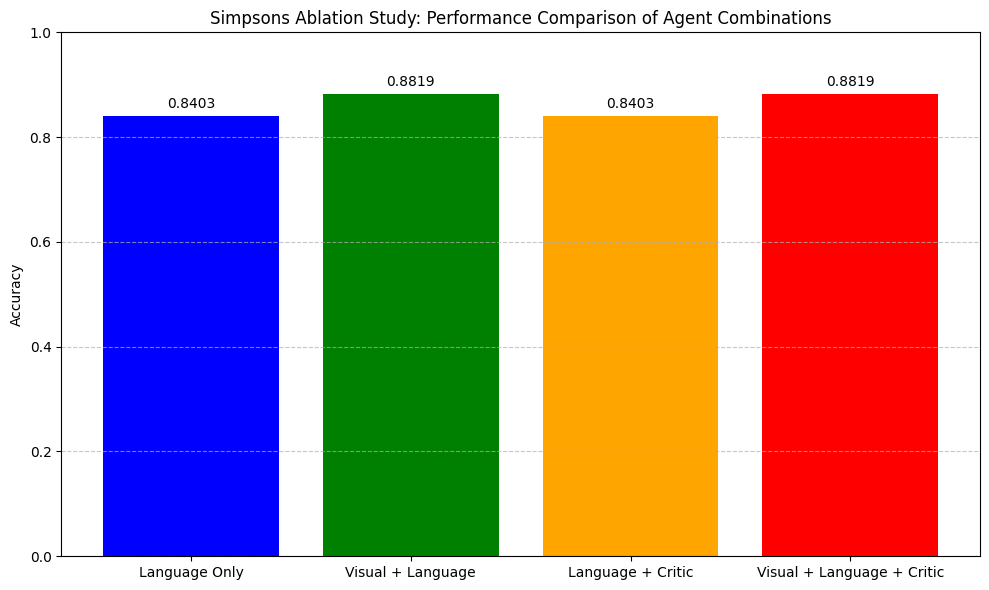


Comparison results saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_comparison_20250530_162923.csv
Final comparison data:
                Configuration  Accuracy
0               Language Only  0.840278
1           Visual + Language  0.881944
2           Language + Critic  0.840278
3  Visual + Language + Critic  0.881944


In [ ]:
# Create visualization of ablation results
# Check if all_accuracies has values - if not, try to load them from CSV files
if not all_accuracies:
    print("No accuracy results in memory. Attempting to load from CSV files...")
    
    # Define configuration names we expect to find
    expected_configs = [
        'language', 
        'visual_language', 
        'language_critic', 
        'visual_language_critic'
    ]
    
    # Safe model name for file pattern matching
    safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
    # Define results_dir variable here to avoid undefined reference
    base_results_dir = os.path.join(os.getcwd(), "results")
    ablation_results_dir = os.path.join(base_results_dir, "ablation")
    
    # Load accuracies from CSV files if they exist
    for config in expected_configs:
        file_path = os.path.join(ablation_results_dir, f'simpsons_ablation_{config}_{safe_model_name}.csv')
        try:
            if (os.path.exists(file_path)):
                df = pd.read_csv(file_path)
                # Get the last row which should be the Average row
                avg_row = df[df['question_id'] == 'Average']
                if not avg_row.empty and 'accuracy' in avg_row.columns:
                    all_accuracies[config] = float(f"{float(avg_row['accuracy'].iloc[0]):.4f}")
                    print(f"Loaded accuracy for {config}: {all_accuracies[config]:.4f}")
                else:
                    # Calculate average from individual rows
                    regular_rows = df[df['question_id'] != 'Average']
                    if not regular_rows.empty and 'accuracy' in regular_rows.columns:
                        all_accuracies[config] = float(f"{float(regular_rows['accuracy'].mean()):.4f}")
                        print(f"Calculated accuracy for {config}: {all_accuracies[config]:.4f}")
        except Exception as e:
            print(f"Error loading results for {config}: {e}")

# If we still don't have accuracy values, use the ones from the notebook state
# Safely access the global accuracies variable if it exists
if 'accuracies' in globals():
    local_accuracies = globals()['accuracies'] if globals()['accuracies'] else []
else:
    local_accuracies = []

if not all_accuracies and local_accuracies:
    # Use the current experiment's results if available
    avg_accuracy = np.mean(local_accuracies) if local_accuracies else 0
    config_name = ''
    if ENABLE_VISUAL_AGENT:
        config_name += 'visual_'
    if ENABLE_LANGUAGE_AGENT:
        config_name += 'language'
    if ENABLE_CRITIC_AGENT:
        config_name += '_critic'
    
    if config_name:
        all_accuracies[config_name] = float(f"{avg_accuracy:.4f}")
        print(f"Using current experiment accuracy for {config_name}: {avg_accuracy:.4f}")

# Create the results dictionary for visualization
results = {
    "Language Only": all_accuracies.get('language', 0),
    "Visual + Language": all_accuracies.get('visual_language', 0),
    "Language + Critic": all_accuracies.get('language_critic', 0),
    "Visual + Language + Critic": all_accuracies.get('visual_language_critic', 0)
}

# Print the values we're using
print("\nAccuracy values used for visualization:")
for config, accuracy in results.items():
    print(f"{config}: {accuracy:.4f}")

# Create a folder to save figures if not exist
os.makedirs("saved_figures", exist_ok=True)

# Generate timestamp for unique figure name
timestamp = time.strftime("%Y%m%d_%H%M%S")
config_name = f"ablation_comparison_{timestamp}"

# Create the visualization
plt.figure(figsize=(10, 6))
bars = plt.bar(results.keys(), results.values(), color=['blue', 'green', 'orange', 'red'])
plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('Simpsons Ablation Study: Performance Comparison of Agent Combinations')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.4f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the figure with a unique name
plt.savefig(f"saved_figures/simpsons_{config_name}.png", dpi=300)
print(f"Visualization saved to: saved_figures/simpsons_{config_name}.png")

plt.show()

# Save the comparison results to CSV
comparison_df = pd.DataFrame([results], index=['Accuracy']).T.reset_index()
comparison_df.columns = ['Configuration', 'Accuracy']
# Format accuracy to 4 decimal places
comparison_df['Accuracy'] = comparison_df['Accuracy'].map(lambda x: f"{x:.4f}")
timestamp = time.strftime("%Y%m%d_%H%M%S")
comparison_path = os.path.join(os.getcwd(), "results", "ablation", f"simpsons_ablation_comparison_{timestamp}.csv")

# Create results directory if it doesn't exist
os.makedirs(os.path.dirname(comparison_path), exist_ok=True)

# Save the comparison file
comparison_df.to_csv(comparison_path, index=False)
print(f"\nComparison results saved to: {comparison_path}")
# 设置pandas显示选项，确保显示4位小数
with pd.option_context('display.float_format', '{:.4f}'.format):
    print(f"Final comparison data:\n{comparison_df}")